----------------------------------------
Step Size: h = 0.01
Eigenvalues: [1.+0.01j 1.-0.01j]
Maximum Magnitude: 1.00005
Status: Solution may not be Entirely Stable ;)


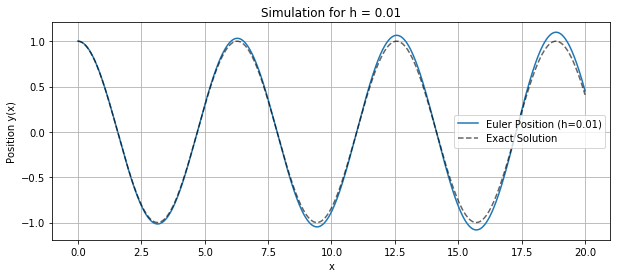

----------------------------------------
Step Size: h = 0.1
Eigenvalues: [1.+0.1j 1.-0.1j]
Maximum Magnitude: 1.00499
Status: Solution may not be Entirely Stable ;)


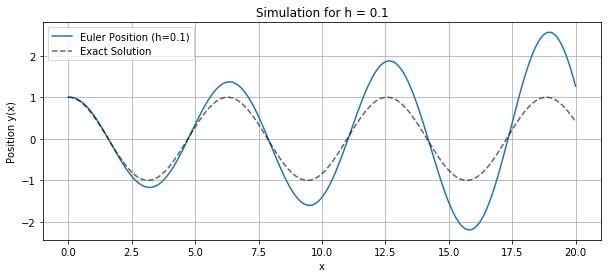

----------------------------------------
Step Size: h = 0.5
Eigenvalues: [1.+0.5j 1.-0.5j]
Maximum Magnitude: 1.11803
Status: Solution may not be Entirely Stable ;)


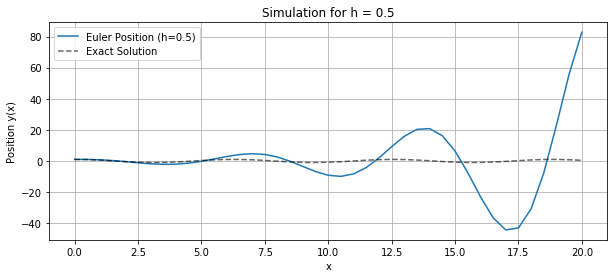

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# System parameter (spring constant from the previous challenge)
k = 1.0

# Array of step sizes to test
h_vals = [0.01, 0.1, 0.5]

# Simulation parameters
x_start = 0
x_end = 20
y_0 = 1.0
v_0 = 0.0

for h in h_vals:
    # 1. Construct the coefficient matrix for Euler's Method
    # State-space form of the system:
    # y_{n+1} = y_n + h * v_n
    # v_{n+1} = -h*k * y_n + v_n
    # 
    # In matrix form: X_{n+1} = A * X_n
    A = np.array([
        [1.0,    h],
        [-h * k, 1.0]
    ])
    
    # 2. Compute the eigenvalues of the matrix A
    eigenvalues = np.linalg.eigvals(A)
    
    # Calculate magnitudes (absolute value handles complex numbers automatically)
    magnitudes = np.abs(eigenvalues)
    max_mag = np.max(magnitudes)
    
    # 3. Output the step size and stability check
    print("-" * 40)
    print(f"Step Size: h = {h}")
    print(f"Eigenvalues: {eigenvalues}")
    print(f"Maximum Magnitude: {max_mag:.5f}")
    
    if max_mag < 1.0:
        print("Status: Solution is Stable")
    else:
        print("Status: Solution may not be Entirely Stable ;)")
        
    # 4. Simulate the numerical solution
    # Calculate number of steps
    N = int(np.ceil((x_end - x_start) / h))
    
    # Initialize a 2D array to hold our states [y, v] over time
    states = np.zeros((2, N + 1))
    states[:, 0] = [y_0, v_0]
    
    x_vals = np.linspace(x_start, x_end, N + 1)
    
    # Loop through and apply the matrix multiplication update
    for i in range(N):
        states[:, i+1] = A @ states[:, i]
        
    # Extract just the position (y) for plotting
    y_vals = states[0, :]
    
    # 5. Visualize the results
    plt.figure(figsize=(10, 4))
    plt.plot(x_vals, y_vals, label=f'Euler Position (h={h})', color='tab:blue')
    
    # Adding the exact solution for reference
    plt.plot(x_vals, np.cos(np.sqrt(k)*x_vals), 'k--', alpha=0.6, label='Exact Solution')
    
    plt.title(f"Simulation for h = {h}")
    plt.xlabel('x')
    plt.ylabel('Position y(x)')
    plt.legend()
    plt.grid(True)
    plt.show()